In [1]:
%load_ext autoreload
%autoreload 2
# %matplotlib ipympl
%config InlineBackend.figure_format='retina'

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch

import sys
sys.path.append('../factorised-MA-AIF/')

from games import *
# from agent import Agent
from network_agent import NetworkAgent
import utils.simulation

INFO:numexpr.utils:NumExpr defaulting to 10 threads.


In [2]:
available_games = {
    'Ch': chicken_2player, 
    # 'PD': prisoners_dilemma_2player, 
    'SH': stag_hunt_2player, 
    # 'Ha': harmony_2player
}

def get_game_name(this_game, available_games):
    for key, game in available_games.items():
        if torch.equal(this_game, game):
            return key
    return None

Simulation: n=10 agents playing 20 games
(0, 4) -- Ch
(0, 6) -- SH
(0, 9) -- SH
(0, 2) -- Ch
(0, 5) -- Ch
(1, 2) -- SH
(1, 8) -- SH
(2, 3) -- SH
(2, 6) -- SH
(2, 9) -- Ch
(3, 9) -- Ch
(3, 7) -- Ch
(3, 8) -- SH
(4, 6) -- Ch
(4, 9) -- Ch
(4, 7) -- SH
(5, 6) -- Ch
(5, 9) -- Ch
(5, 7) -- SH
(7, 8) -- SH


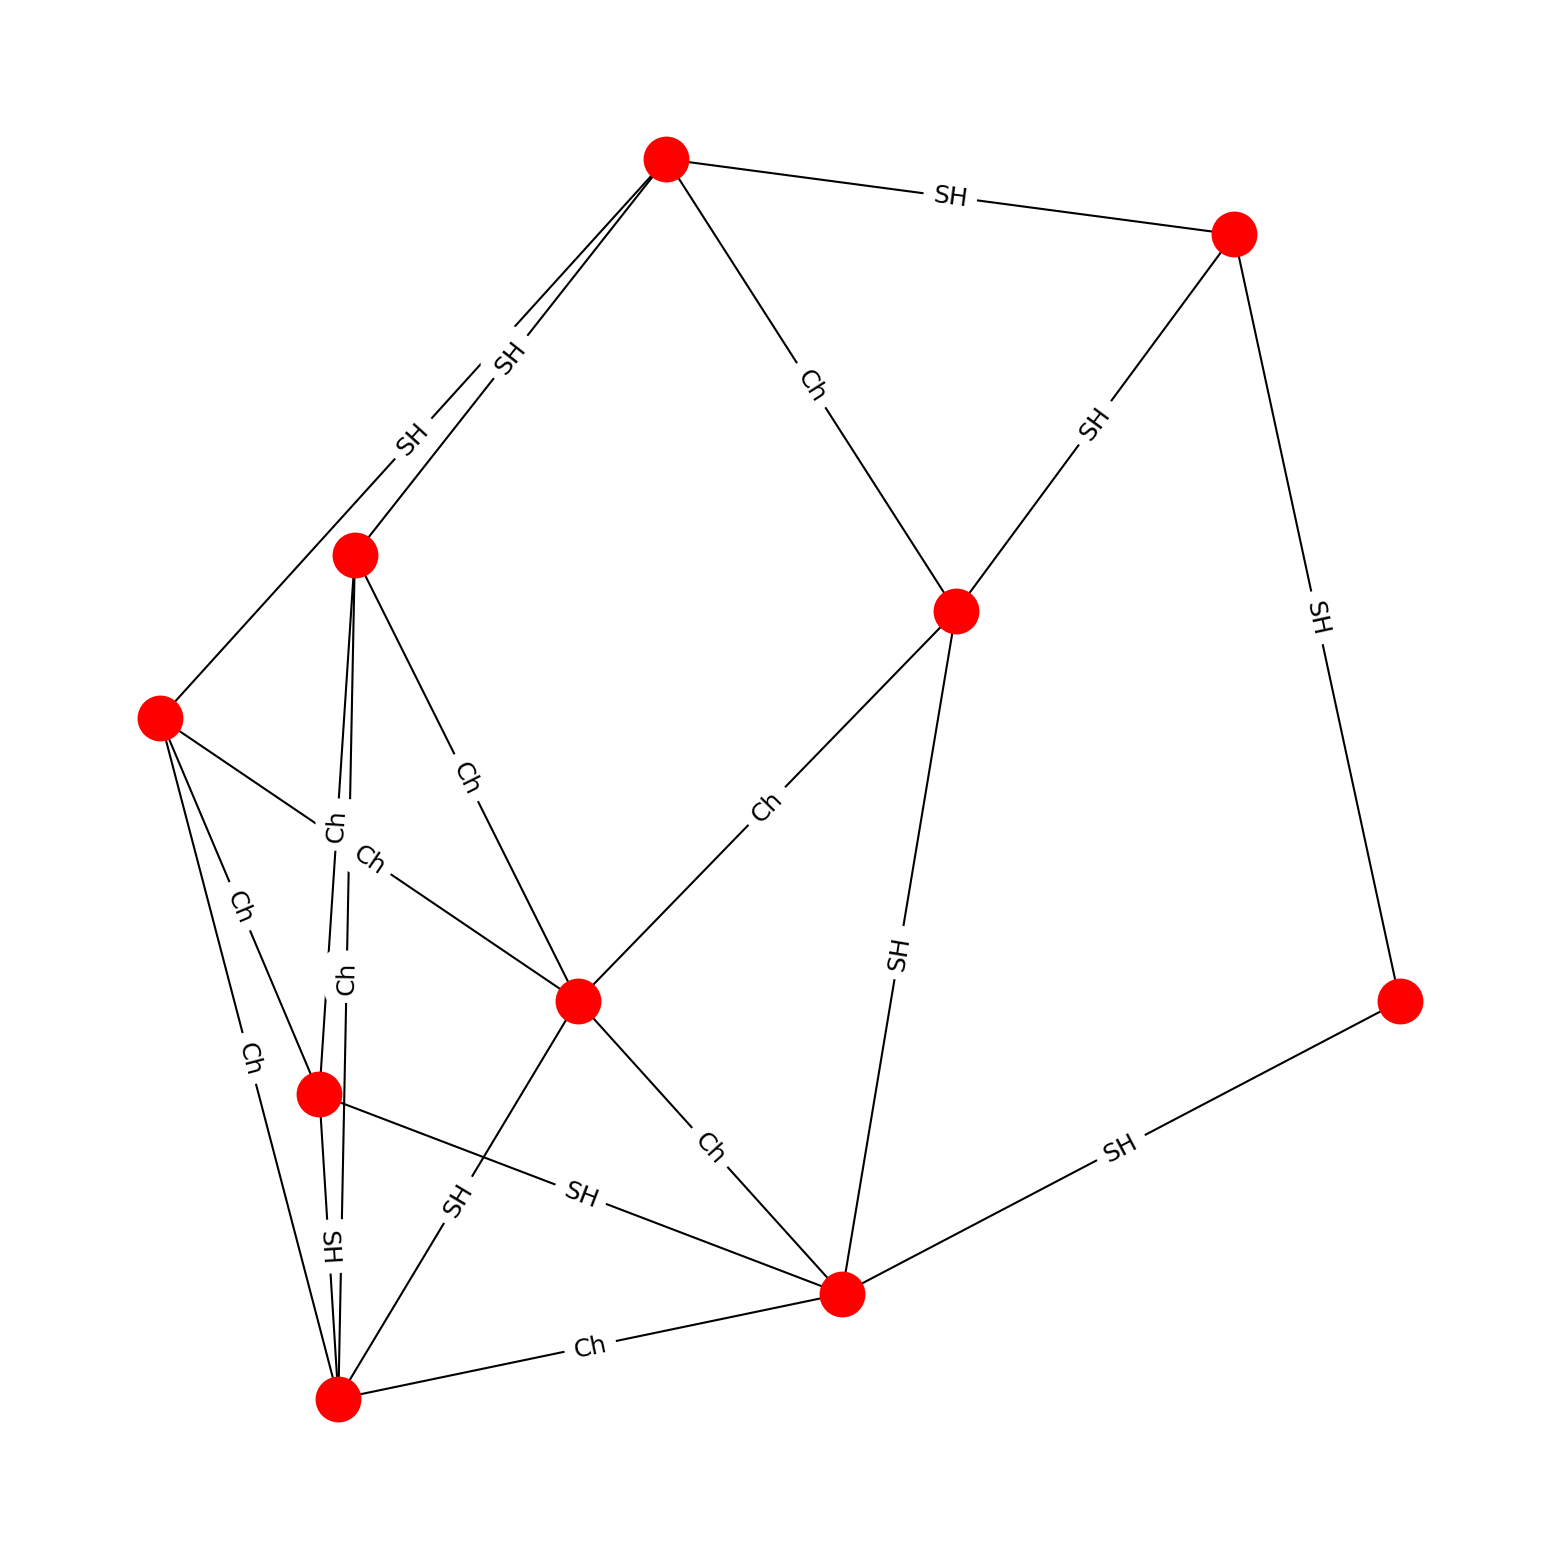

In [11]:
# Predefined constants
n = 10  # Number of nodes
p = 0.9 # Probability of edge creation

# Generate an Erdős-Rényi network
G = nx.watts_strogatz_graph(n, 4, p)

# Assign a random game to each edge in the graph
for edge in G.edges:
    G.edges[edge]['game'] = list(available_games.values())[np.random.randint(len(available_games))]

# List the edges and their corresponding games
print(f"Simulation: n={G.number_of_nodes()} agents playing {G.number_of_edges()} games")
for edge in G.edges(data=True):
    game = edge[2]['game']
    game_name = get_game_name(game, available_games)
    print(f"{edge[:2]} -- {game_name}")

# Plot the network
plt.figure(figsize=(5, 5), dpi=150)
pos = nx.spring_layout(G)
nx.draw(
    G, 
    pos, 
    with_labels=False, 
    node_size=100, 
    node_color='red', 
    edge_color='black', 
    width=0.5
)
edge_labels = {(edge[0], edge[1]): get_game_name(edge[2]['game'], available_games) for edge in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
plt.show()

In [12]:
T = 100
num_players = len(G.nodes)  # Number of players (nodes in the graph)

agent_kwargs = [                                                                # <--- Define agent configurations here
    dict(
        beta_1=300.,
        dynamic_precision=True,
        decay=0.9,
        # A_learning=False,
        learn_every_t_steps=10,
        learning_offset=8,
    )
] * num_players

# Initialisation ---------------------------------------------------------------
agents = []
for node in G.nodes:
    adjacent_games = [G.edges[edge]['game'] for edge in G.edges(node)]
    agents.append(
        NetworkAgent(
            id=node, 
            game_matrices=adjacent_games, 
            **agent_kwargs[node]
        )
    )

# Instantiate the simulator object
ig = utils.simulation.IteratedNetworkGame(agents=agents, network=G, seed=None)

# Simulation -------------------------------------------------------------------
variables_history = ig.run(T)

INFO:root:Simulation started with seed 5
INFO:root:t=0/100
INFO:root:t=0/100
INFO:root:t=100/100 Simulation complete


## Plotting

Text(0, 0.5, 'q_u')

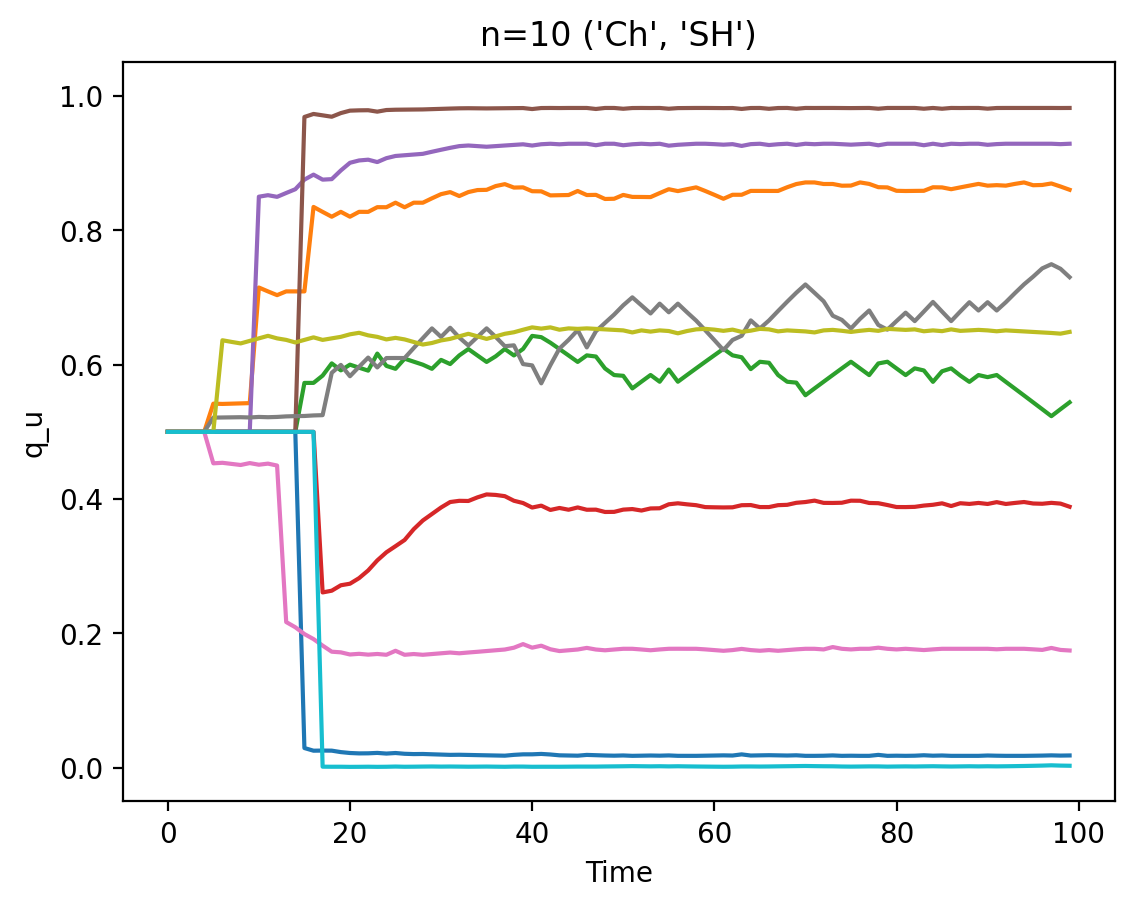

In [13]:
MARGIN = 0.05
q_u_history = np.array(variables_history['q_u'])
for i in range(num_players):
    plt.plot(q_u_history[:, i, 0], label='Agent 0')  # indices: time, agent, action
plt.ylim(0-MARGIN, 1+MARGIN)
plt.title(f'n={len(G.nodes)} {tuple(available_games.keys())}')
plt.xlabel('Time')
plt.ylabel('q_u')

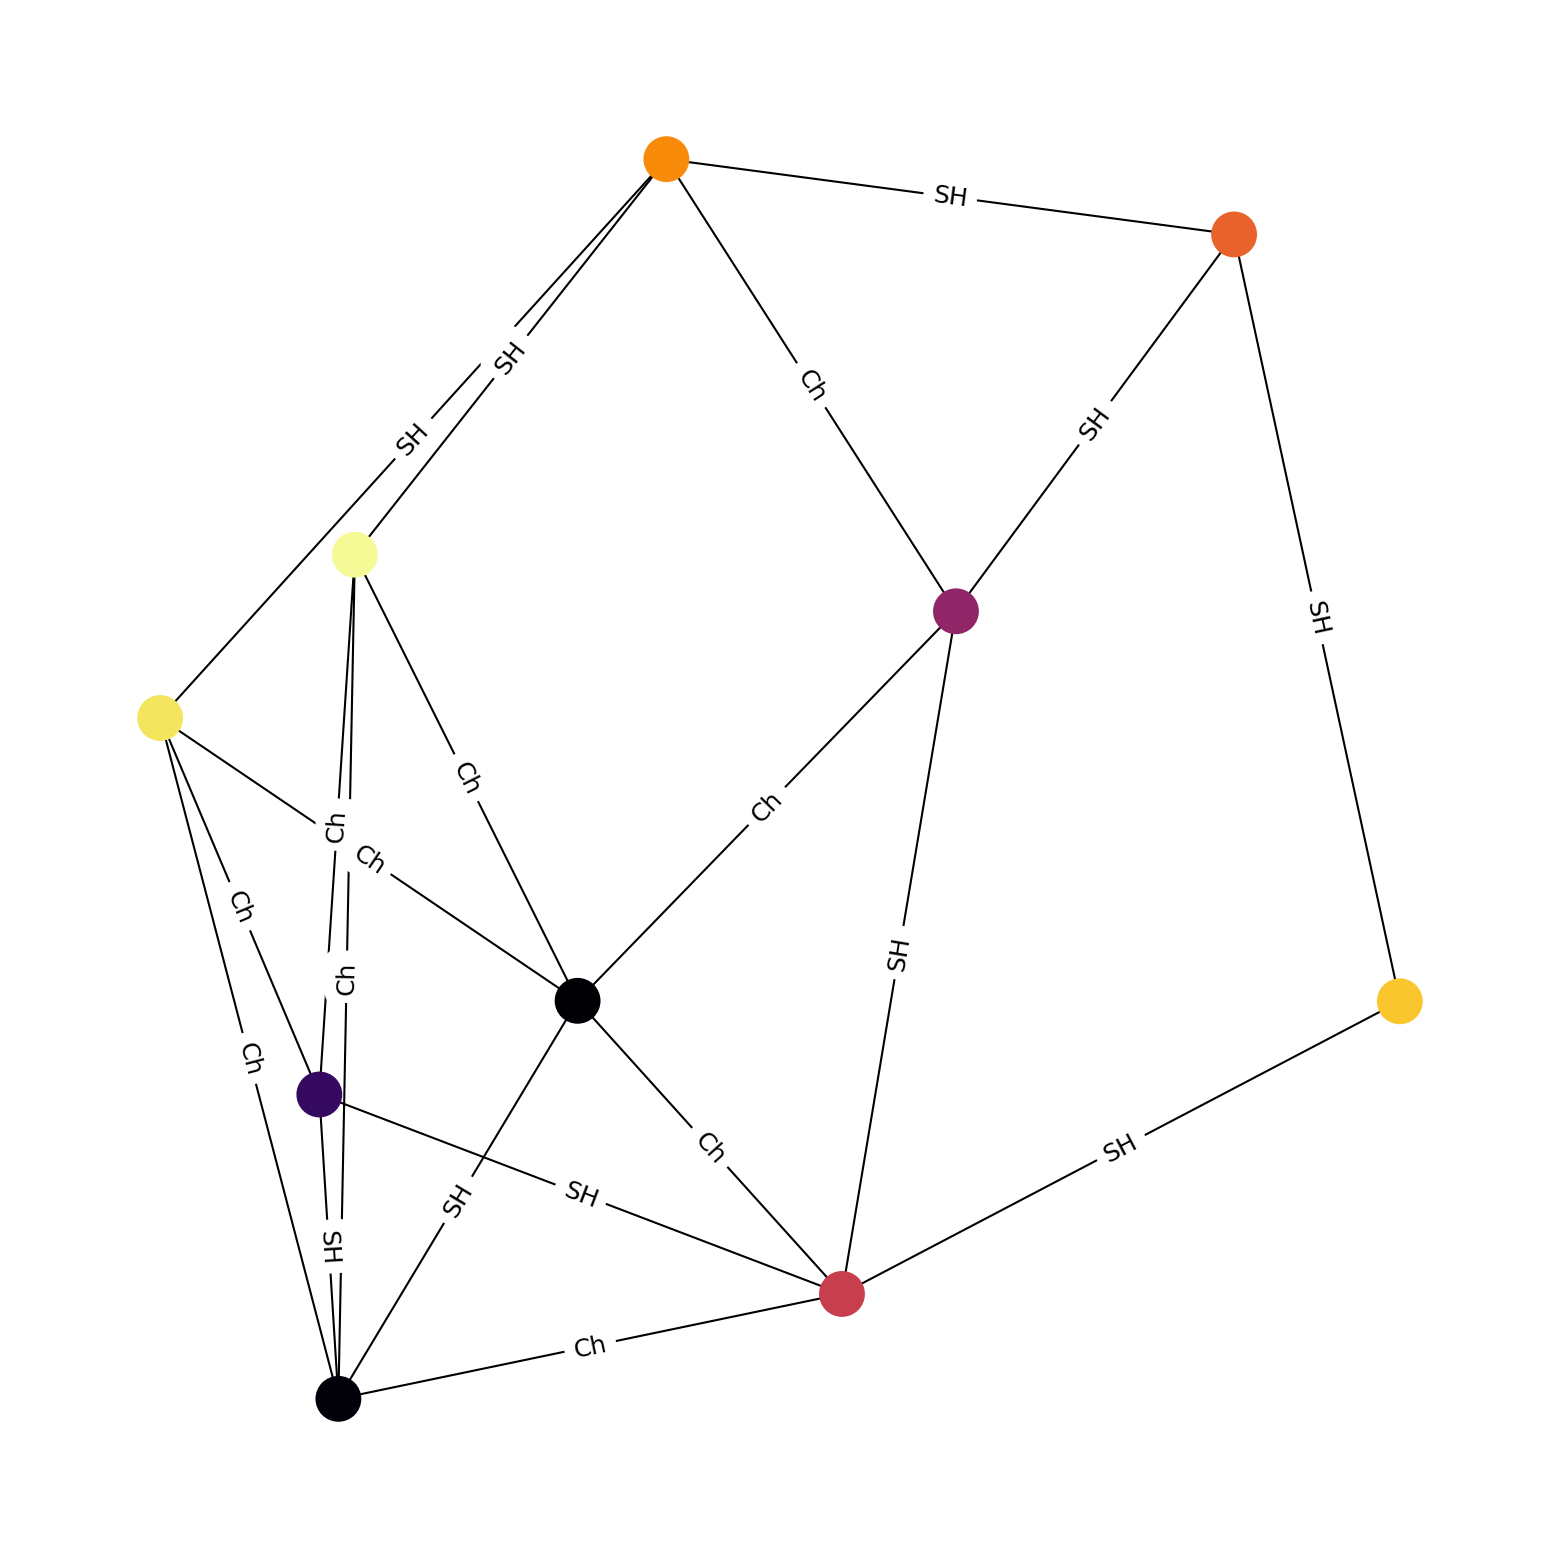

In [14]:
node_intensity = q_u_history[-2, :, 0]  # Extract node intensities
plt.figure(figsize=(5, 5), dpi=150)
nx.draw(
    G, 
    pos, 
    with_labels=False, 
    node_size=100, 
    node_color=node_intensity, 
    vmin=0, 
    vmax=1, 
    edge_color='black', 
    cmap=plt.cm.inferno,
    width=0.5
)
edge_labels = {(edge[0], edge[1]): get_game_name(edge[2]['game'], available_games) for edge in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
plt.show()

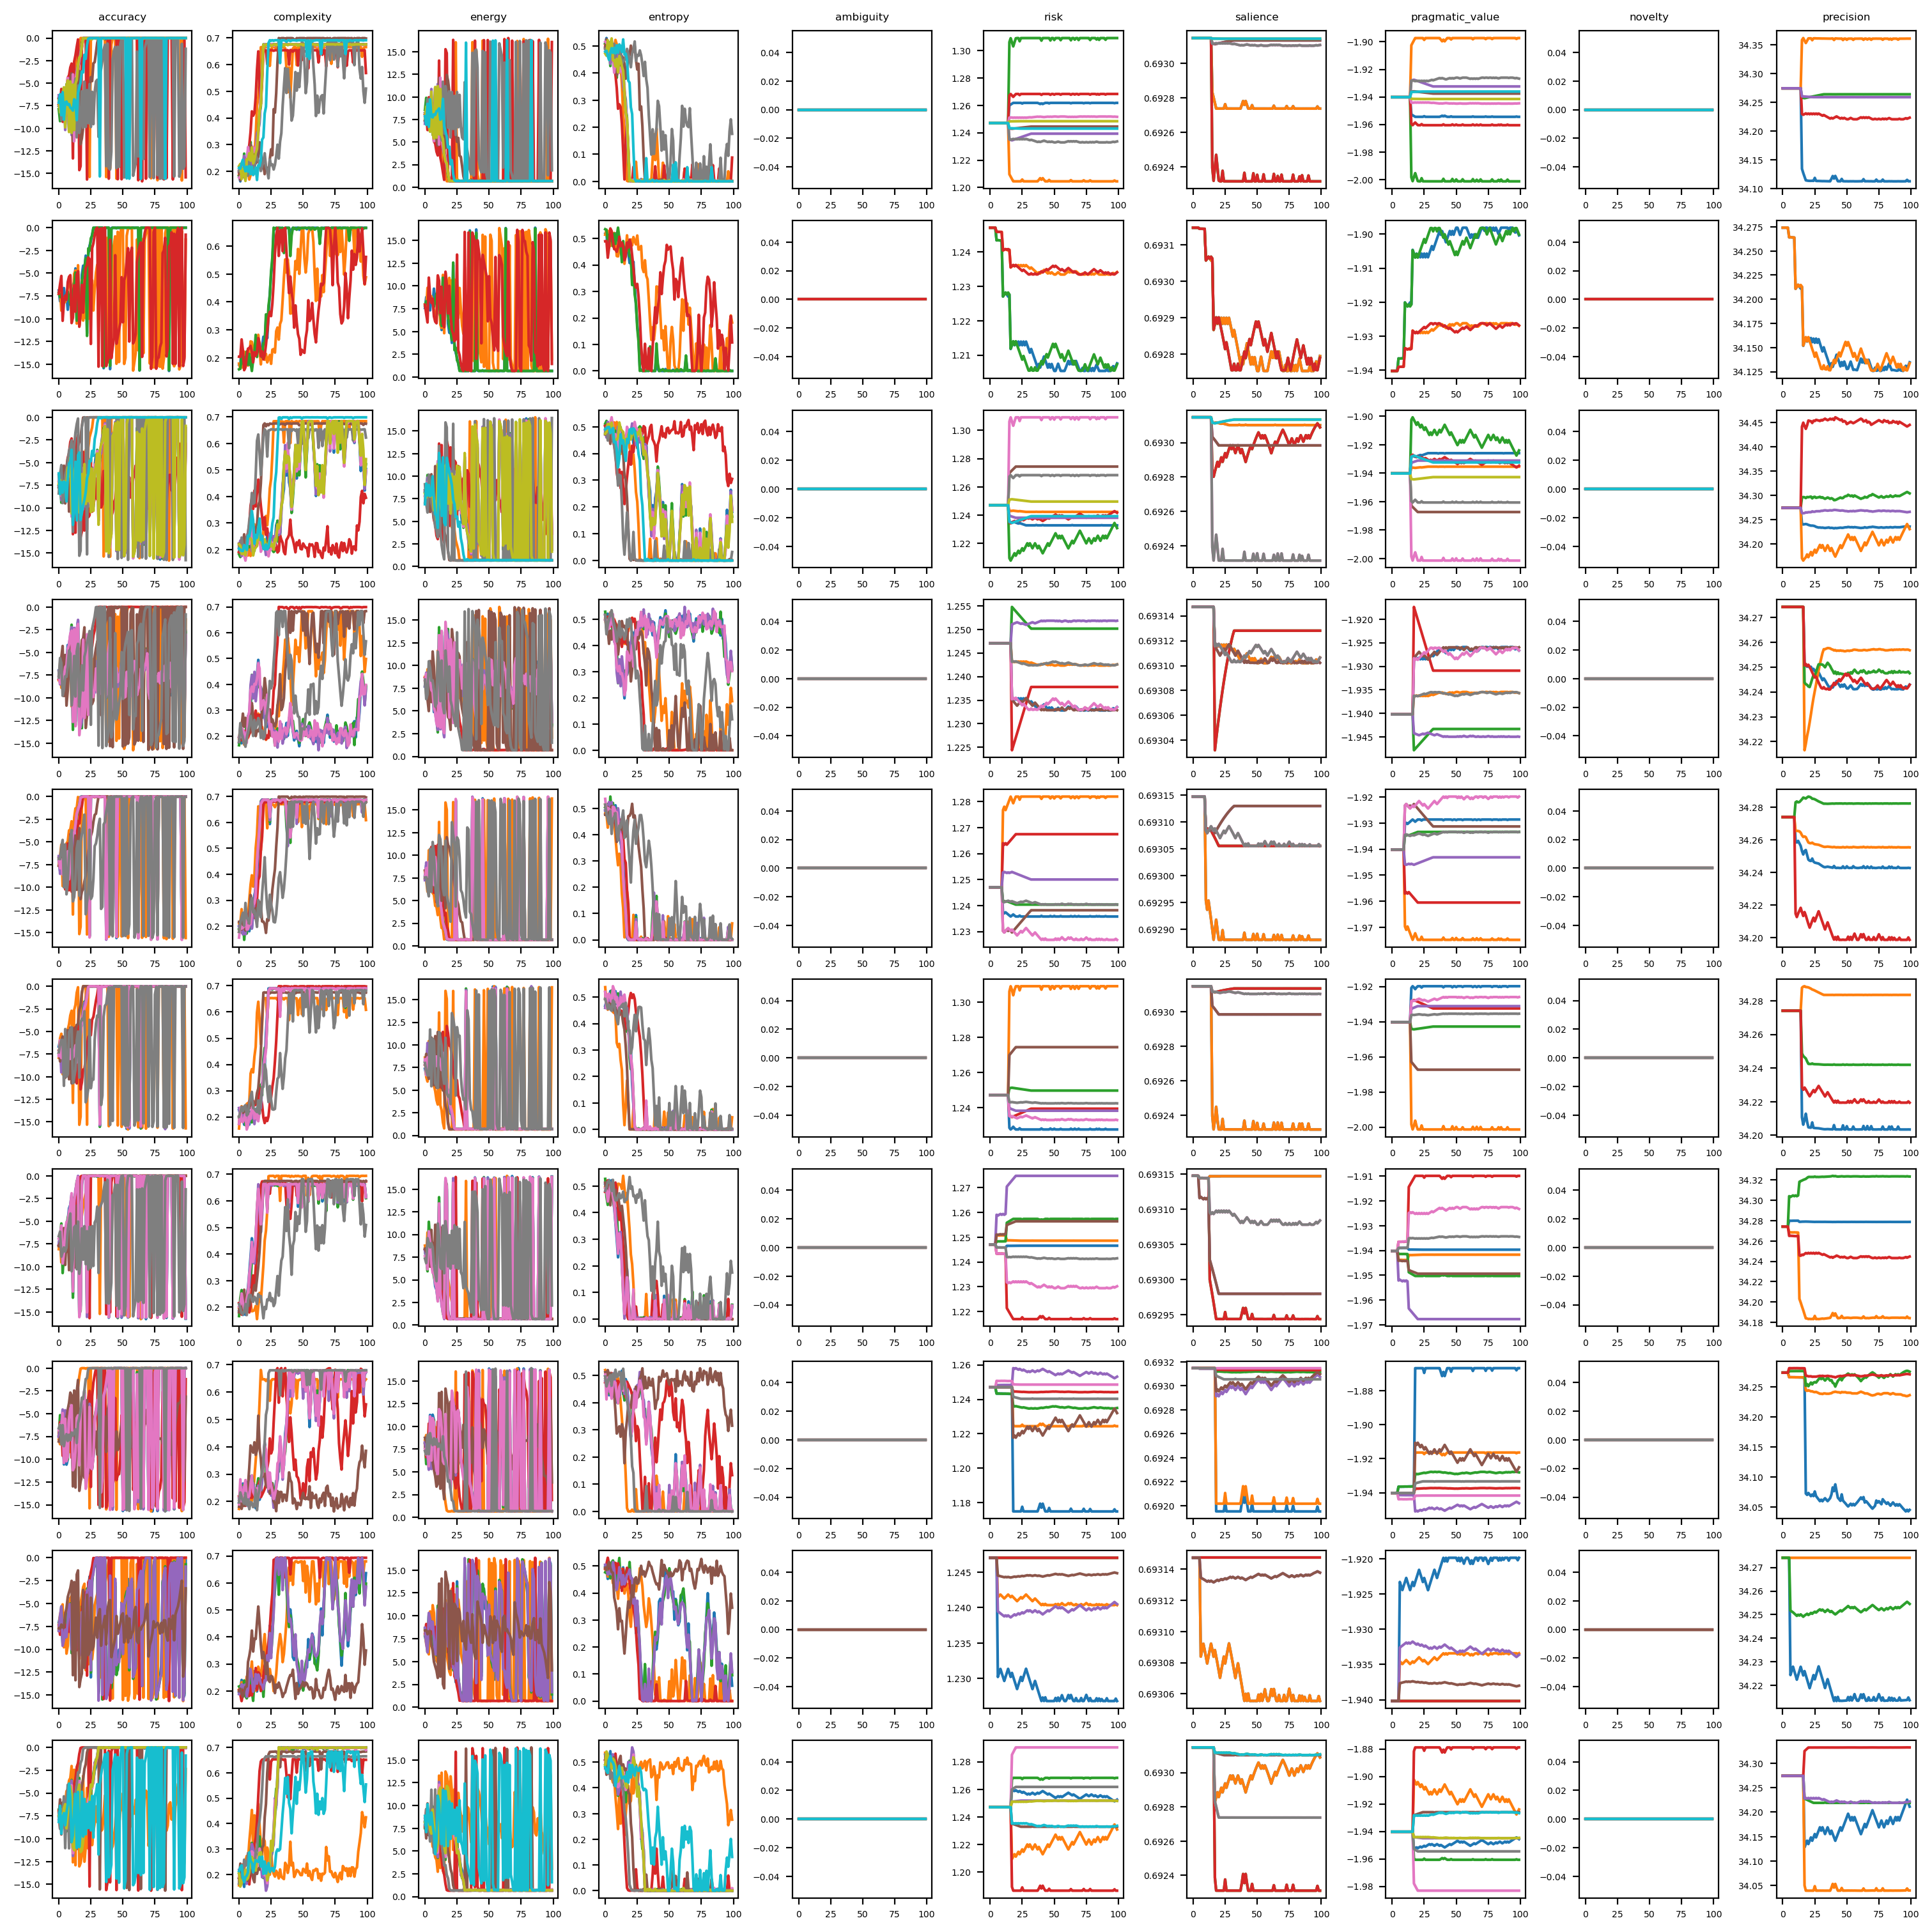

In [15]:
variable_names = list(variables_history['generative_models_data'][0][0][0].keys())
# variable_name = 'complexity'

plt.rc('font', size=5)
fig, axs = plt.subplots(
    num_players, 
    len(variable_names), 
    figsize=(15, 15), 
    constrained_layout=True
)
axs = axs.flatten()
for idx, ax in enumerate(axs):
    variable_name = variable_names[idx%len(variable_names)]
    i = idx // len(variable_names)

    data = []
    for t in range(T):
        data.append([
            game[variable_name]
            for game in variables_history['generative_models_data'][t][i]
        ])

    data = np.array(data)

    for j in range(data.shape[1]):
        ax.plot(data[:, j], label=f'Agent {j}')

        if i == 0:  # Add titles to each column
            ax.set_title(variable_name)

## Superagents

In [16]:
from itertools import combinations

L_max = 1  # number of hops
# TODO: For L_max > 1, the procedure below is not correct --
#       It will "create" edges that are not in the graph
superagents = []
for node in G.nodes:
    # Get all neighbors within L_max hops
    neighbors = nx.single_source_shortest_path_length(G, node, cutoff=L_max)
    # Get all combinations of edges at distance l
    for l in range(1, L_max + 1):
        edges_at_distance_l = [
            tuple(sorted([node, neighbor])) 
            for neighbor, distance in neighbors.items() 
            if distance == l
        ]
        combinations_at_distance_l = []
        for superagent_size in range(1, len(edges_at_distance_l) + 1):
            combinations_at_distance_l += \
                list(combinations(edges_at_distance_l, superagent_size))
        # Filter out combinations that are already in superagents
        superagents += [
            combination for combination in combinations_at_distance_l 
            if combination not in superagents
        ]

superagents
len(superagents)

158

In [17]:
get_superagent_members = lambda x: sorted(set().union(*x))

for edge_tuple in superagents[:10]:
    # Get the list of unique nodes in the edge tuple
    print(get_superagent_members(edge_tuple))

[0, 4]
[0, 6]
[0, 9]
[0, 2]
[0, 5]
[0, 4, 6]
[0, 4, 9]
[0, 2, 4]
[0, 4, 5]
[0, 6, 9]


Superagent: [0, 2, 4, 5]
Superagent: [0, 2, 6, 9]
Superagent: [0, 5, 6, 9]
Superagent: [0, 2, 5, 6]
Superagent: [0, 2, 5, 9]
Superagent: [0, 2, 4, 6, 9]
Superagent: [0, 4, 5, 6, 9]
Superagent: [0, 2, 4, 5, 6]
Superagent: [0, 2, 4, 5, 9]
Superagent: [0, 2, 5, 6, 9]
Superagent: [0, 2, 4, 5, 6, 9]
Superagent: [1, 2]
Superagent: [1, 8]
Superagent: [1, 2, 8]
Superagent: [2, 3]
Superagent: [2, 6]
Superagent: [2, 9]
Superagent: [1, 2, 3]
Superagent: [0, 1, 2]
Superagent: [1, 2, 6]
Superagent: [1, 2, 9]
Superagent: [0, 2, 3]
Superagent: [2, 3, 6]
Superagent: [2, 3, 9]
Superagent: [0, 2, 6]
Superagent: [0, 2, 9]
Superagent: [2, 6, 9]
Superagent: [0, 1, 2, 3]
Superagent: [1, 2, 3, 6]
Superagent: [1, 2, 3, 9]


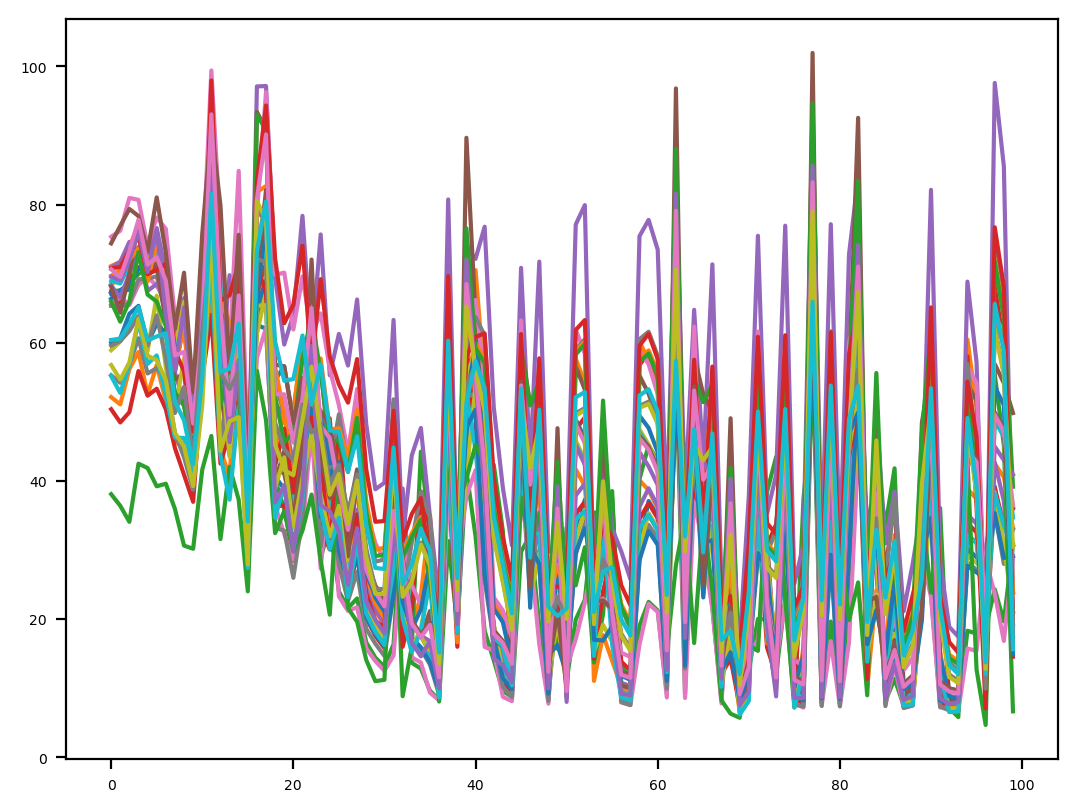

In [18]:

for superagent in superagents[20:50]:
    members = get_superagent_members(superagent)
    print(f"Superagent: {members}")
    joint_efe = []
    joint_vfe = []
    for t in range(T):
        joint_vfe.append(0)
        joint_efe.append(0)
        for i in members:
            for gm_data in variables_history['generative_models_data'][t][i]:
                joint_vfe[t] += torch.sum(gm_data['complexity'] - gm_data['accuracy']) / len(members)
                joint_efe[t] += torch.sum(-gm_data['salience'] -gm_data['pragmatic_value'] -gm_data['novelty']) / len(members)
                # print(gm_data['salience'] - gm_data['pragmatic_value'] - gm_data['novelty'])

    plt.plot(joint_vfe)
    # plt.plot(joint_efe)

Superagent: [0, 2, 4, 5, 6, 9]
Superagent: [1, 2]
Superagent: [1, 8]


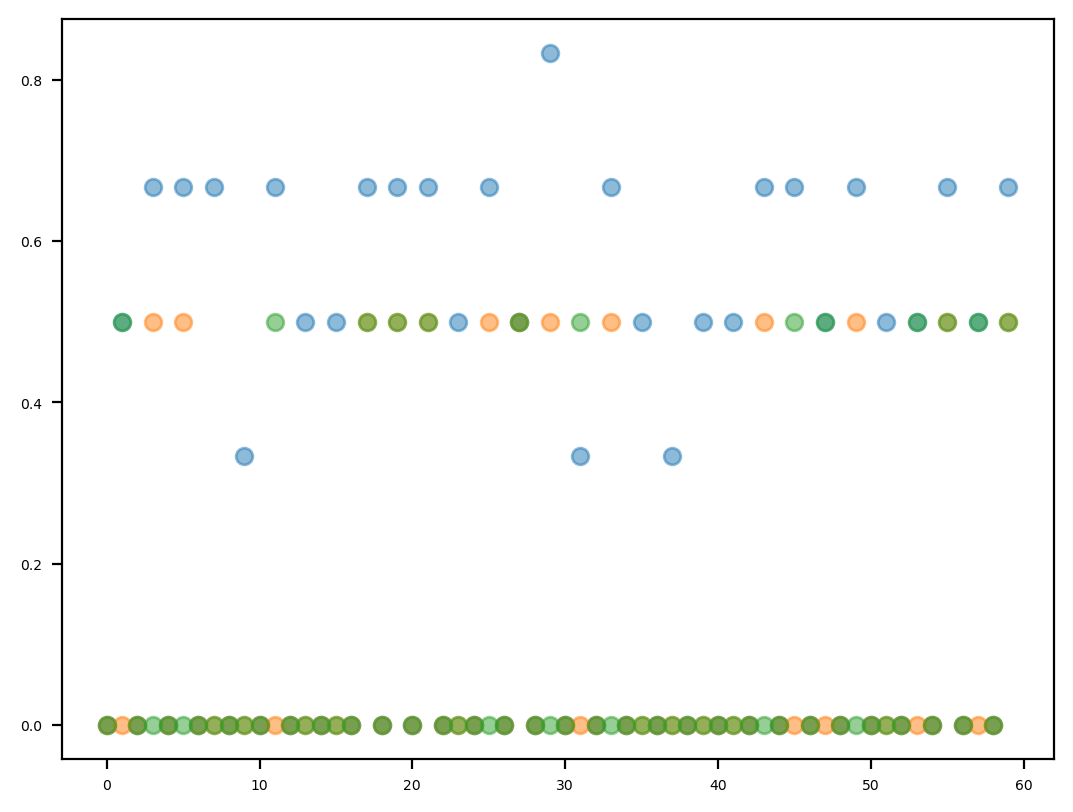

In [19]:
for superagent in superagents[30:33]:
    members = get_superagent_members(superagent)
    print(f"Superagent: {members}")
    average_actions = []
    for t in range(50, 80):
        average_actions.append(0)
        value = 0
        for i in members:
            value += variables_history['u'][t][i]
        average_actions.append(value/len(members))
            
    plt.scatter(np.arange(len(average_actions)), average_actions, label=f"Superagent {members}", alpha=0.5)
    # plt.plot(joint_efe)

In [20]:
# Check that there are no made up edges in superagents
edges_list = list(G.edges)
for edge_tuple in superagents:
    for edge in edge_tuple:
        if edge not in edges_list:
            print(f"Edge {edge} not in graph")

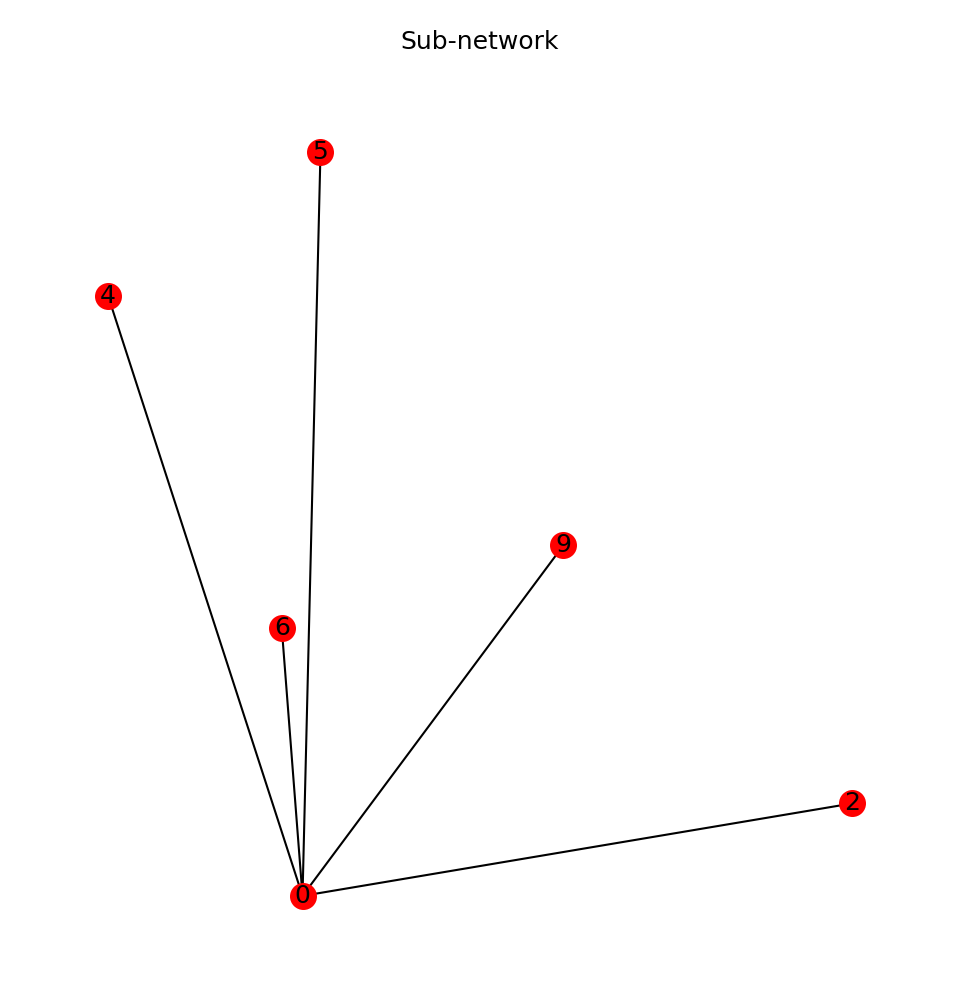

In [21]:
# Create a subgraph from the edges in edge_tuple
subgraph = G.edge_subgraph(superagents[30])

# Plot the subgraph
plt.figure(figsize=(3, 3), dpi=150)
pos_subgraph = {node: pos[node] for node in subgraph.nodes}
nx.draw(
    subgraph,
    pos_subgraph,
    with_labels=True,
    node_size=30,
    node_color='red',
    edge_color='black',
    width=0.5,
    font_size=6  # Set label size smaller
)
plt.title("Sub-network")
plt.show()

In [26]:
get_superagent_members(superagent)

[0, 2, 4, 5, 6, 9]

In [ ]:
def get_superagent_graph(G, superagent):
    # Create a subgraph from the edges in edge_tuple
    subgraph = G.edge_subgraph(superagent)
    # Add edges between nodes in get_superagent_members(superagent) to the subgraph
    members = get_superagent_members(superagent)
    additional_edges = [
        edge for edge in G.edges(members) 
        if edge not in subgraph.edges
        and edge[0] in members 
        and edge[1] in members
    ]
    subgraph = G.edge_subgraph(list(subgraph.edges) + additional_edges)
    return subgraph

def get_environment_and_blanket_graphs(G, superagent_graph):
    # Get the neighbors of the subgraph nodes
    neighbors = set()
    for node in superagent_graph.nodes:
        neighbors.update(G.neighbors(node))
    neighbors.difference_update(superagent_graph.nodes)

    # Create a subgraph for the neighbors and their edges
    neighbor_edges = [(n, nbr) for n in neighbors for nbr in G.neighbors(n) if nbr in superagent_graph.nodes]
    boundary_subgraph = G.edge_subgraph(neighbor_edges)

    environment_nodes = boundary_subgraph.nodes - superagent_graph.nodes
    environment_graph = G.subgraph(environment_nodes)

    blanket_graph = nx.intersection(boundary_subgraph, superagent_graph)

    return environment_graph, blanket_graph, boundary_subgraph

In [78]:
superagent_idx = 30
superagent = superagents[superagent_idx]
superagent_graph = get_superagent_graph(G, superagent)
environment_graph, blanket_graph, boundary_subgraph = get_environment_and_blanket_graphs(G, superagent_graph)

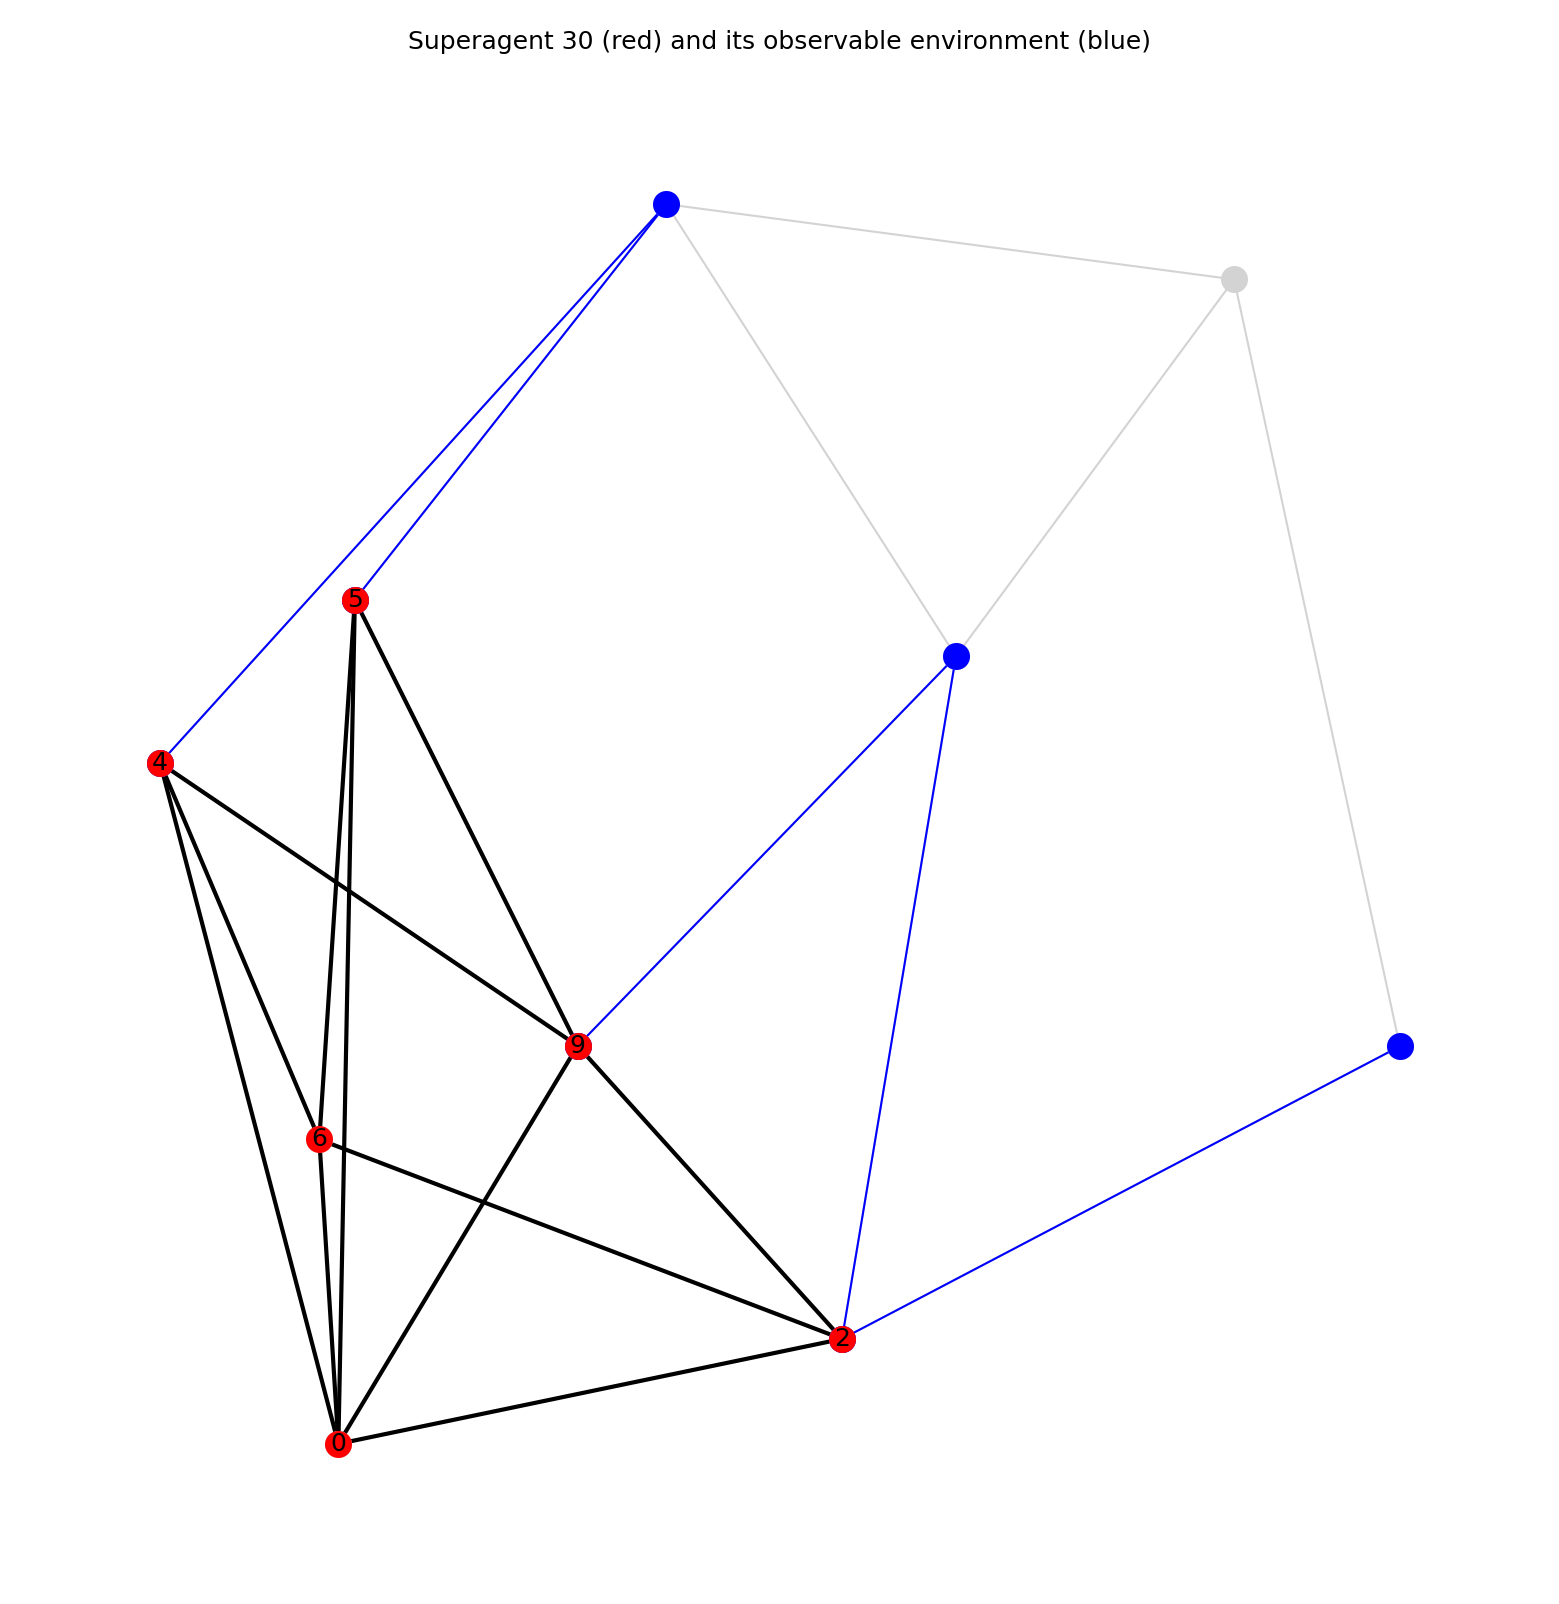

In [79]:
# Plot the subgraph and its neighbors
plt.figure(figsize=(5, 5), dpi=150)

# Main graph -----------------------------------------
nx.draw(
    G, 
    pos, 
    with_labels=False, 
    node_size=30, 
    node_color='lightgray', 
    edge_color='lightgray', 
    width=0.5
)

# Blanket --------------------------------------
# nx.draw(
#     blanket_graph,
#     {node: pos[node] for node in blanket_graph.nodes},
#     with_labels=True,
#     node_size=100,
#     node_color=(255, 255, 255, 255),  # Transparent nodes
#     edge_color='black',
#     width=0.5,
#     font_size=6,
#     edgecolors='green'  # Red node outlines
# )

# Neighbors --------------------------------------
nx.draw(
    boundary_subgraph,
    {node: pos[node] for node in boundary_subgraph.nodes},
    with_labels=False,
    node_size=30,
    node_color='blue',
    edge_color='blue',
    width=0.5
)

# Superagent --------------------------------------
nx.draw(
    superagent_graph,
    {node: pos[node] for node in superagent_graph.nodes},
    with_labels=True,
    node_size=30,
    node_color='red',
    edge_color='black',
    width=1.0,
    font_size=6
)

plt.title(f"Superagent {superagent_idx} (red) and its observable environment (blue)")
plt.show()

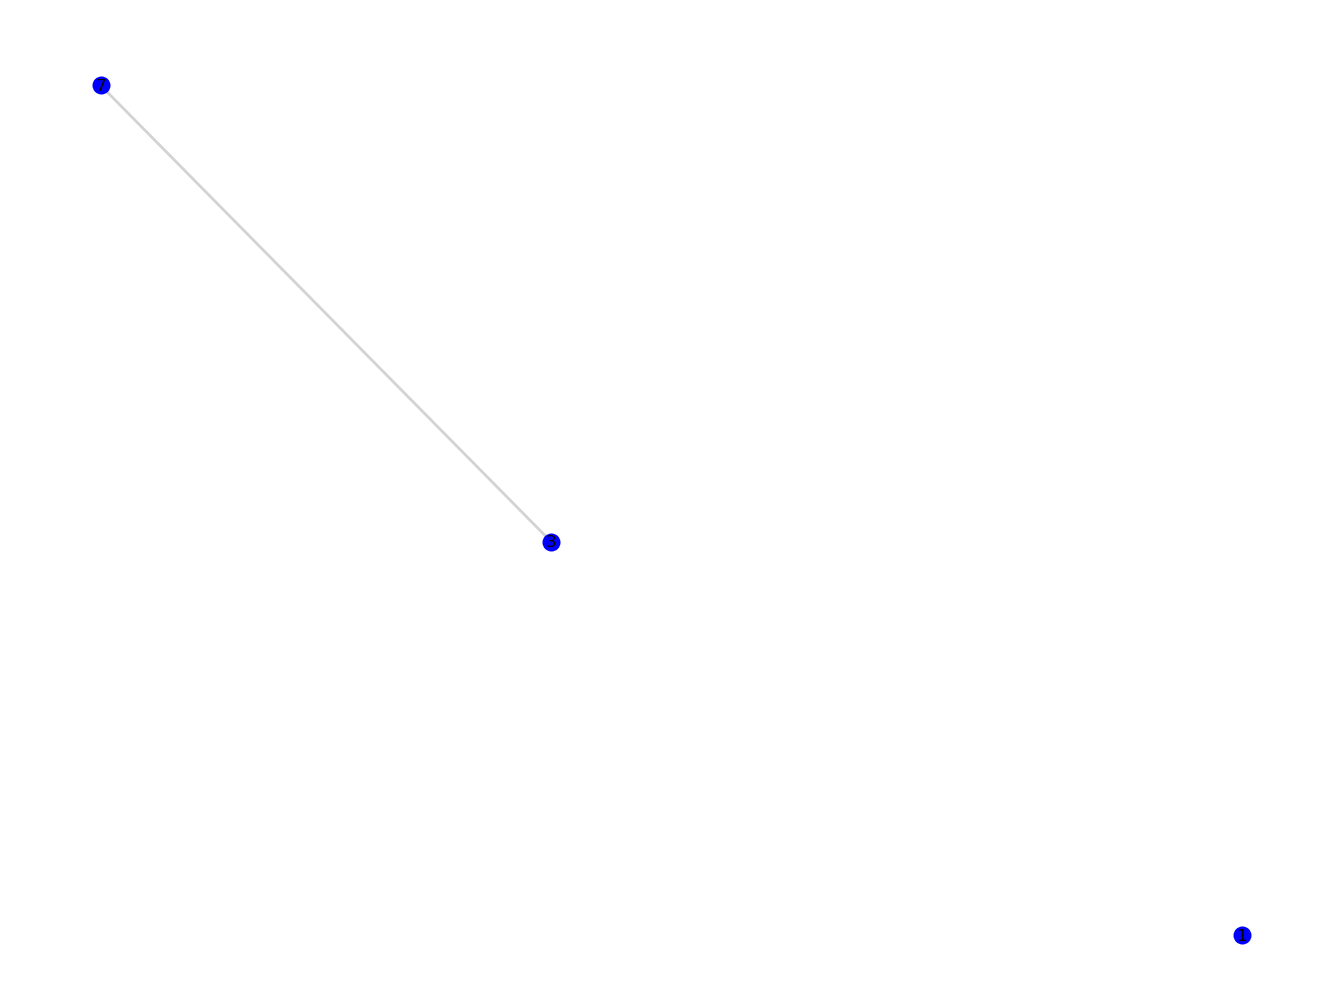

In [80]:
nx.draw(
    environment_graph,
    {node: pos[node] for node in environment_graph.nodes},
    with_labels=True,
    node_size=30,
    node_color='blue',
    edge_color='lightgray',
    width=1.0,
    font_size=6
)

Stored 'main_graph' (Graph)
Stored 'superagents' (list)
Stored 'variables_history' (dict)


In [84]:
def get_internal_and_env_timeseries(variables_history, superagent_graph, environment_graph):
    # Get the internal and environment timeseries
    S_timeseries = []
    E_timeseries = []
    for t in range(T):
        S_timeseries.append([])
        for i in superagent_graph.nodes:
            S_timeseries[t].append(variables_history['u'][t][i])
        E_timeseries.append([])
        for j in environment_graph.nodes:
            E_timeseries[t].append(variables_history['u'][t][j])

    S_timeseries = np.array(S_timeseries)
    E_timeseries = np.array(E_timeseries)
    return S_timeseries, E_timeseries

In [85]:
superagent_idx = 30
superagent = superagents[superagent_idx]

superagent_graph = get_superagent_graph(G, superagent)
environment_graph, blanket_graph, boundary_subgraph = get_environment_and_blanket_graphs(G, superagent_graph)
S_timeseries, E_timeseries = get_internal_and_env_timeseries(variables_history, superagent_graph, environment_graph)

In [86]:
all_partition_timeseries = []
for superagent in superagents:
    superagent_graph = get_superagent_graph(G, superagent)
    environment_graph, blanket_graph, boundary_subgraph = get_environment_and_blanket_graphs(G, superagent_graph)
    S_timeseries, E_timeseries = get_internal_and_env_timeseries(variables_history, superagent_graph, environment_graph)
    all_partition_timeseries.append((S_timeseries, E_timeseries))

In [87]:
%store all_partition_timeseries

Stored 'all_partition_timeseries' (list)
